# Level 2 Task 1:
Table Booking and Online DeliveryDetermine the percentage of restaurants thatoffer table booking and online delivery.Compare the average ratings of restaurantswith table booking and those without.Analyze the availability of online deliveryamong restaurants with different price ranges

In [7]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# task 1
data = pd.read_csv("Dataset.csv")

# 3. Percentage of Table Booking
table_booking_percent = data['Has Table booking'].value_counts(normalize=True) * 100
print("Percentage of Table Booking:\n", table_booking_percent)



# 4. Percentage of Online Delivery
online_delivery_percent = data['Has Online delivery'].value_counts(normalize=True) * 100
print("\nPercentage of Online Delivery:\n", online_delivery_percent)

Percentage of Table Booking:
 Has Table booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64

Percentage of Online Delivery:
 Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


In [9]:
#Compare the average ratings of restaurantswith table booking and those without
# 5. Average Rating (Table Booking vs No)
table_rating = data.groupby('Has Table booking')['Aggregate rating'].mean()
print("\nAverage Rating (Table Booking vs No):\n", table_rating)



# 6. Average Rating (Online Delivery vs No)
delivery_rating = data.groupby('Has Online delivery')['Aggregate rating'].mean()
print("\nAverage Rating (Online Delivery vs No):\n", delivery_rating)


Average Rating (Table Booking vs No):
 Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64

Average Rating (Online Delivery vs No):
 Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


In [10]:
# Analyze the availability of online delivery among restaurants with different price ranges
delivery_price_percent = pd.crosstab(
    data['Price range'],
    data['Has Online delivery'],
    normalize='index'
) * 100
print("\nOnline Delivery vs Price Range (Percentage):\n", delivery_price_percent)



Online Delivery vs Price Range (Percentage):
 Has Online delivery         No        Yes
Price range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369


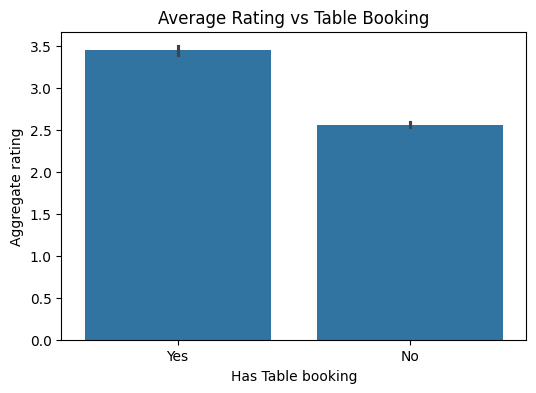

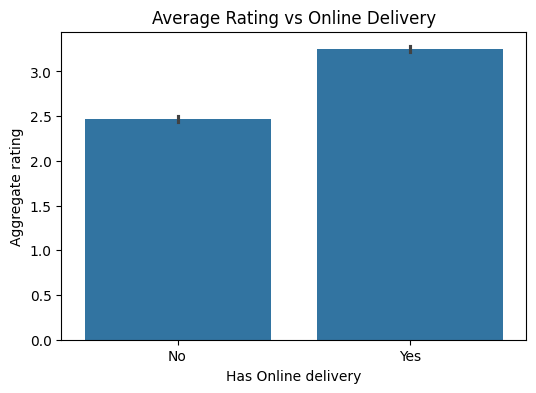

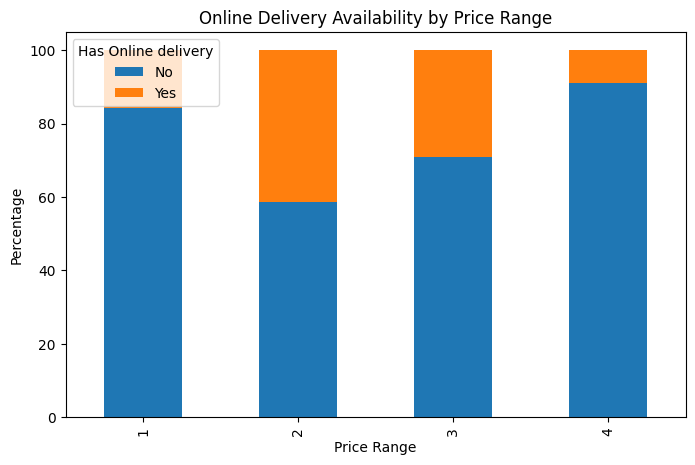

In [11]:
# visualizations
# --- Table Booking vs Rating ---

plt.figure(figsize=(6,4))
sns.barplot(x='Has Table booking', y='Aggregate rating', data=data)
plt.title("Average Rating vs Table Booking")
plt.show()

# --- Online Delivery vs Rating ---
plt.figure(figsize=(6,4))
sns.barplot(x='Has Online delivery', y='Aggregate rating', data=data)
plt.title("Average Rating vs Online Delivery")
plt.show()

# --- Online Delivery vs Price Range ---
delivery_price_percent.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage")
plt.show()

# Level 2 Task 2: Price Range Analysis
Determine the most common price range among all the restaurants. Calculate the average rating for each price range. Identify the color that represents the highest average rating among different price ranges.

In [12]:
# Most common price range
most_common_price = data['Price range'].value_counts()
print("Most Common Price Range:\n", most_common_price)

Most Common Price Range:
 Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [13]:
# average rating for each price range
avg_rating_price = data.groupby('Price range')['Aggregate rating'].mean()
print("\nAverage Rating for each Price Range:\n", avg_rating_price)


Average Rating for each Price Range:
 Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


In [14]:
# color represents the highest average rating
color_rating = data.groupby('Rating color')['Aggregate rating'].mean()
print("\nAverage Rating by Color:\n", color_rating)


Average Rating by Color:
 Rating color
Dark Green    4.659801
Green         4.168119
Orange        3.051619
Red           2.297849
White         0.000000
Yellow        3.683429
Name: Aggregate rating, dtype: float64


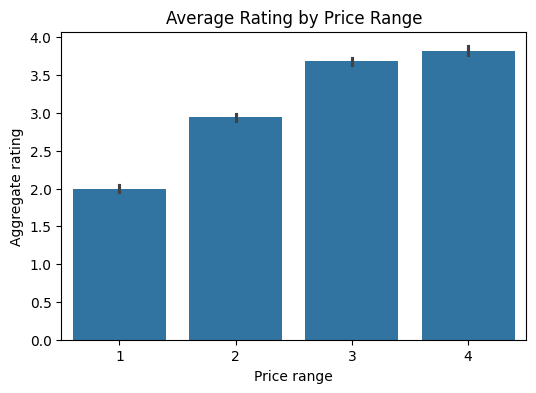

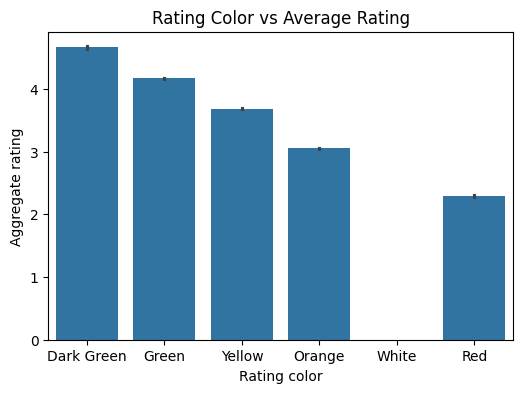

In [15]:
# visualisations
# Price range vs rating
plt.figure(figsize=(6,4))
sns.barplot(x='Price range', y='Aggregate rating', data=data)
plt.title("Average Rating by Price Range")
plt.show()

# Rating color vs rating
plt.figure(figsize=(6,4))
sns.barplot(x='Rating color', y='Aggregate rating', data=data)
plt.title("Rating Color vs Average Rating")
plt.show()

# Level 2 Task 3: Feature Engineering
Extract additional features from the existing columns, such as the length of the restaurant name or address. Create new features like "Has Table Booking"or "Has Online Delivery" by encoding categorical variables.

In [16]:
#creating new features (length of name and address)
data['Name Length'] = data['Restaurant Name'].apply(len)
data['Address Length'] = data['Address'].apply(len)
print(data[['Restaurant Name', 'Name Length']].head())

          Restaurant Name  Name Length
0        Le Petit Souffle           16
1        Izakaya Kikufuji           16
2  Heat - Edsa Shangri-La           22
3                    Ooma            4
4             Sambo Kojin           11


In [17]:
# encode categorical variables
data['Table Booking'] = data['Has Table booking'].map({'Yes': 1, 'No': 0})
data['Online Delivery'] = data['Has Online delivery'].map({'Yes': 1, 'No': 0})

print(data[['Has Table booking', 'Table Booking']].head())

  Has Table booking  Table Booking
0               Yes              1
1               Yes              1
2               Yes              1
3                No              0
4               Yes              1


In [18]:
# additional features
data['Num Cuisines'] = data['Cuisines'].apply(lambda x: len(str(x).split(',')))
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Price range,Aggregate rating,Rating color,Rating text,Votes,Name Length,Address Length,Table Booking,Online Delivery,Num Cuisines
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,3,4.8,Dark Green,Excellent,314,16,71,1,0,3
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,3,4.5,Dark Green,Excellent,591,16,67,1,0,1
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,4,4.4,Green,Very Good,270,22,56,1,0,4
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,4,4.9,Dark Green,Excellent,365,4,70,0,0,2
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,4,4.8,Dark Green,Excellent,229,11,64,1,0,2
